## Example 3: multiclass classification 

<mark>The goal of multiclass classification is to assign an input data example $x$ to one of K >2
classes, so $y \in \{1,2,...,K\}$. </mark>

Real-world examples include (i) predicting which of K = 10
digits $y$ is present in an image $x$ of a handwritten number and (ii) predicting which of K
possible words $y$ follows an incomplete sentence $x$.

Following the recipe for maximum likelihood estimation, we first choose a distribution over the prediction space $y$. In this case, we have $y \in \{1,2,...,K\}$, so we choose the categorical distribution, which is defined on this domain. This has $K$
parameters $\lambda_1,\lambda_2,...,\lambda_K$, which determine the probability of each category:

\begin{eqnarray}
 Pr(y=k) = \lambda_{k}.
 \end{eqnarray}

<img src="assets/Chap05/LossCategorical.svg" style="filter: invert(1);" align="right" width="40%">

<mark>The
categorical distribution assigns probabilities
to $K>2$ categories, with associated
probabilities $\lambda_1, \lambda_2, . . . , \lambda_K$.</mark>

 To ensure
that this is a valid probability distribution,
<mark>each parameter $\lambda_k$ must lie in the
range [0, 1], and all $K$ parameters must
sum to one.</mark>

The parameters are constrained to take values between zero and one, and they must
collectively sum to one to ensure a valid probability distribution.

Then we use a network $f[\mathbf{x},\boldsymbol\phi]$ with $K$ outputs to compute these $K$ parameters from
the input $\mathbf{x}$. <mark>Unfortunately, the network outputs will not necessarily obey the afore-
mentioned constraints. Consequently, we pass the $K$ outputs of the network through a
function that ensures these constraints are respected. A suitable choice is the softmax
function</mark> (figure 5.10). 

Softmax takes an arbitrary vector of length $K$ and returns a vector
of the same length but where the elements are now in the range [0,1] and sum to one.

$$ \text{softmax}_k(\mathbf{z}) = \frac{\exp[z_k]}{\sum_{k'=1}^{K}\exp[z_{k'}]} $$

where the exponential function ensure that all elements of the resulting vector are positive, which helps in satisfying the constraints of a valid probability distribution. So for example, for a network with three output nodes $D_o = 3$ and $I$ training samples i.e. $\text{logit} \in \mathbb{R}^{I \times 3}$, the softmax function will produce an $I \times 3$ matrix where each row sums to one and contains non-negative values.

---

<img src="assets/Chap05/LossMultiClassClassification.svg" style="filter: invert(1);" width="100%"> 

Multiclass classification for $K=3$ classes. a) The network has three piecewise linear outputs, which can take arbitrary values. b) After the softmax function, these outputs are constrained to be non-negative and sum to one. Hence, for a given input x, we compute valid parameters for the categorical distribution: any vertical slice of this plot produces three values that sum to one and would form the heights of the bars in a categorical distribution similar to figure above.

---

The likelihood that input x has label $y= k$ is hence:


\begin{eqnarray}
  Pr(y=k|\mathbf{x}) = \mbox{softmax}_{k}\Bigr[\mbox{\bf f}[\mathbf{x},\boldsymbol\phi]\Bigl].
 \end{eqnarray}

The loss function is the negative log-likelihood of the training data:

\begin{eqnarray}\label{eq:loss_multiclass_class}
  L[\boldsymbol\phi] &=& -\sum_{i=1}^{I}\log\left[\mbox{softmax}_{y_{i}}\Bigl[\mbox{\bf f}\left[\mathbf{x}_i,\boldsymbol\phi\right]\Bigr]\right]\nonumber\\
  &=& -\sum_{i=1}^{I}\left(\mbox{f}_{y_{i}}\left[\mathbf{x}_i,\boldsymbol\phi\right]-\log\left[\sum_{k'=1}^{K}\exp\left[\mbox{ f}_{k'}\left[\mathbf{x}_i,\boldsymbol\phi\right]\right]\right]\right),
 \end{eqnarray}

where $f_{y_i}[\mathbf{x}_i,\boldsymbol\phi]$ and $f_{k'}[\mathbf{x}_i,\boldsymbol\phi]$ denote the $y_i$th and $k'$th outputs of the network, respectively.

For reasons that will be explained later, <mark>this is known as the multiclass cross-entropy loss.</mark>

The transformed model output represents a categorical distribution over possible classes $y \in \{1,2,...,K\}$. For a point estimate, we take the most probable category

$$
\hat{y} = \arg\max_k Pr(y= k|\mathbf{f}[\mathbf{x},\boldsymbol\phi]).
$$

This corresponds to whichever curve is highest for that value of x. 


In [19]:
# Imports math library
import numpy as np
# Used for repmat
import numpy.matlib
# Imports plotting library
import matplotlib.pyplot as plt
# Import math Library
import math

plt.style.use('dark_background')
     

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define a shallow neural network
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Make sure that input data is (1 x n_data) array
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # This runs the network for ALL of the inputs, x at once so we can draw graph
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    model_out = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return model_out
     

# Get parameters for model -- we can call this function to easily reset them
def get_parameters():
  # And we'll create a network that approximately fits it
  beta_0 = np.zeros((3,1));  # formerly theta_x0
  omega_0 = np.zeros((3,1)); # formerly theta_x1
  beta_1 = np.zeros((3,1));  # NOTE -- there are three outputs now (one for each class, so three output biases)
  omega_1 = np.zeros((3,3)); # NOTE -- there are three outputs now (one for each class, so nine output weights, connecting 3 hidden units to 3 outputs)

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 2.0; beta_1[1,0] = -2; beta_1[2,0] = 0.0
  omega_1[0,0] = -24.0; omega_1[0,1] = -8.0; omega_1[0,2] = 50.0
  omega_1[1,0] = -2.0; omega_1[1,1] = 8.0; omega_1[1,2] = -30.0
  omega_1[2,0] = 16.0; omega_1[2,1] = -8.0; omega_1[2,2] =-8

  return beta_0, omega_0, beta_1, omega_1
     

# Utility function for plotting data
def plot_multiclass_classification(x_model, out_model, lambda_model, x_data = None, y_data = None, title= None):
  # Make sure model data are 1D arrays
  n_data = len(x_model)
  n_class = 3
  x_model = np.squeeze(x_model)
  out_model = np.reshape(out_model, (n_class,n_data))
  lambda_model = np.reshape(lambda_model, (n_class,n_data))

  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(7.0, 3.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_model,out_model[0,:],'r-')
  ax[0].plot(x_model,out_model[1,:],'g-')
  ax[0].plot(x_model,out_model[2,:],'b-')
  ax[0].set_xlabel('Input, $x$'); ax[0].set_ylabel('Model outputs')
  ax[0].set_xlim([0,1]);ax[0].set_ylim([-4,4])
  if title is not None:
    ax[0].set_title(title)
  ax[1].plot(x_model,lambda_model[0,:],'r-')
  ax[1].plot(x_model,lambda_model[1,:],'g-')
  ax[1].plot(x_model,lambda_model[2,:],'b-')
  ax[1].set_xlabel('Input, $x$'); ax[1].set_ylabel('$\lambda$ or Pr(y=k|x)')
  ax[1].set_xlim([0,1]);ax[1].set_ylim([-0.1,1.05])
  if title is not None:
    ax[1].set_title(title)
  if x_data is not None:
    for i in range(len(x_data)):
      if y_data[i] ==0:
        ax[1].plot(x_data[i],-0.05, 'r.')
      if y_data[i] ==1:
        ax[1].plot(x_data[i],-0.05, 'g.')
      if y_data[i] ==2:
        ax[1].plot(x_data[i],-0.05, 'b.')
  plt.show()

For multiclass classification, the network must predict the probability of $K$ classes, using $K$ outputs. However, these probability must be non-negative and sum to one, and the network outputs can take arbitrary values. Hence, we pass the outputs through a softmax function which maps $K$ arbitrary values to $K$ non-negative values that sum to one.

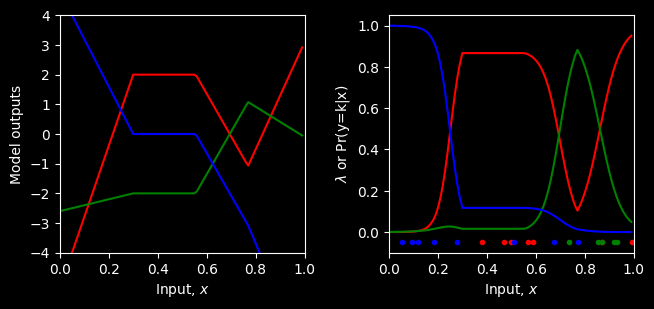

In [20]:
# Softmax function that maps a vector of arbitrary values to a vector of values that are positive and sum to one.
def softmax(model_out):
  # This operation has to be done separately for every column of the input
  # Compute exponentials of all the elements
  # TODO: compute the softmax function (eq 5.22)
  # Replace this skeleton code

  # model_out = model_out - np.max(model_out, axis=1, keepdims=True)  # For numerical stability
  exp_model_out = np.exp(model_out)  # Compute the exponentials of the stabilized model outputs
  sum_exp_model_out = np.sum(exp_model_out, axis=0, keepdims=True)  # Compute the sum of the exponentials (denominator of equation 5.22)
  softmax_model_out = exp_model_out / sum_exp_model_out  # Normalize the exponentials to get the softmax output
  return softmax_model_out

# Let's create some 1D training data
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([2,0,1,2,1,0,\
                    0,2,2,0,2,0,\
                    2,0,1,2,1,2, \
                    1,0])

# Get parameters for the model
beta_0, omega_0, beta_1, omega_1 = get_parameters()

# Define a range of input values
x_model = np.arange(0,1,0.01)
# Run the model to get values to plot and plot it.
model_out= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = softmax(model_out)
plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train)


### Predicting other data types 

In this chapter, we have focused on regression and classification because these problems
are widespread. However, to make different types of predictions, we simply choose an
appropriate distribution over that domain and apply the recipe in section 5.2. Figure 5.11
enumerates a series of probability distributions and their prediction domains. Some of these are explored in the problems at the end of the chapter

| Data Type | Domain | Distribution | Use |
|-----------|--------|--------------|-----|
| univariate, continuous, unbounded | $y \in \mathbb{R}$ | Univariate Normal | Regression |
| univariate, continuous, unbounded | $y \in \mathbb{R}$ | Laplace or t-Distribution | Robust Regression |
| univariate, continuous, unbounded | $y \in \mathbb{R}$ | Mixture of Gaussians | Multimodal Regression |
| univariate, continuous, bounded below | $y \in \mathbb{Z}^+$ | Exponential or Gamma | Predicting Magnitude |
| univariate, continuous, bounded | $y \in \{0, 1\}$ | beta | Predicting proportions |
| univariate, continuous, unbounded | $y \in \mathbb{R}^K$ | Multivariate normal | Multivariate Regression |
| univariate, continuous, circular | $y \in [-\pi, \pi]$ | Von Mises | Predicting Direction |
| univariate, discrete, binary | $y \in \{0, 1\}$ | Bernoulli | Binary Classification |
| univariate, discrete, bounded | $y \in \{1, 2, ..., K\}$ | Categorical | Multiclass Classification |
| univariate, discrete, bounded below | $y \in \{0, 1, 2, 3,...\}$ | Poisson | Predicting event counts |
| multivariate, discrete, permutation | $y \in \text{Perm}[1, 2, ..., K]$ | Plackett-Luce | Ranking Data |



## Multiple outputs

Often, we wish to make more than one prediction with the same model, so the target output $y$ is a vector. For example, we might want to predict a molecule’s melting and boiling point (a multivariate regression problem, figure 1.2b) or the object class at every point in an image (a multivariate classification problem, figure 1.4a). While it is possible to define multivariate probability distributions and use a neural network to model their parameters as a function of the input, it is more usual to treat each prediction as independent.
Independence implies that we treat the probability $Pr(y|f[x,\boldsymbol\phi])$ as a product of univariate terms for each element $y_d \in y$:

\begin{eqnarray}\label{eq:loss_multiple}
 Pr(\mathbf{y}|\mbox{\bf f}[\mathbf{x},\boldsymbol\phi])= \prod_{d}Pr(y_{d}|\mbox{\bf f}_d[\mathbf{x},\boldsymbol\phi]),
 \end{eqnarray}

 where $f_d[\mathbf{x},\boldsymbol\phi]$ is the $d$th set of network outputs, which describe the parameters of the
distribution over $y_d$. For example, to predict multiple continuous variables $y_d \in \mathbb{R}$, we
use a normal distribution for each $y_d$, and the network outputs $f_d[\mathbf{x},\boldsymbol\phi]$ predict the means
of these distributions. To predict multiple discrete variables $y_d \in \{1,2,...,K\}$, we use a categorical distribution for each $y_d$. Here, each set of network outputs $f_d[\mathbf{x},\boldsymbol\phi]$ predicts
the $K$ values that contribute to the categorical distribution for $y_d$.

When we minimize the negative log probability, this product becomes a sum of terms:



\begin{eqnarray}
 L[\boldsymbol\phi] = -\sum_{i=1}^{I}\log\Bigl[Pr(\mathbf{y}_i|\mbox{\bf f}[\mathbf{x}_{i},\boldsymbol\phi])\Bigr]= -\sum_{i=1}^{I}\sum_{d}\log\Bigl[Pr(y_{id}|\mbox{\bf f}_d[\mathbf{x}_{i},\boldsymbol\phi])\Bigr].
 \end{eqnarray}

where $y_{id}$ is the $d$th output from the $i$th training example.
To make two or more prediction types simultaneously, we similarly assume the errors
in each are independent. For example, to predict wind direction and strength, we might
choose the von Mises distribution (defined on circular domains) for the direction and
the exponential distribution (defined on positive real numbers) for the strength. The
independence assumption implies that the joint likelihood of the two predictions is the
product of individual likelihoods. These terms will become additive when we compute
the negative log-likelihood.

## Cross-entropy loss

So far we've developed loss functions that minimize negative log-likelihood. However, the term cross-entropy loss is also commonplace. In this section, we describe the cross-entropy loss and show that it is equivalent to using negative log-likelihood.

Cross entropy loss is based on Kullback-Leibler (KL) divergence, which measures the difference between two probability distributions: 

$$
D_{KL}\bigl[q||p\bigr] = \int_{-\infty}^{\infty}q(z) \log\bigl[\frac{q(z)}{p(z)}\bigr]dz.
$$ 

For the case of discrete probability distributions, the KL divergence becomes a sum over the possible outcomes:

$$
D_{KL}\bigl[q||p\bigr] = \sum_{z} q(z) \log\bigl[\frac{q(z)}{p(z)}\bigr].
$$

A smaller KL divergence indicates that the two distributions are more similar, while a larger KL divergence indicates greater dissimilarity. 

If the distributions are identical, the ratio $\frac{q(z)}{p(z)}$ is equal to 1 for all $z$, and since $\log(1) = 0$, the KL divergence is zero.

So essentially, <mark>KL divergence is weighted sum of the log differences between the two distributions, with the weights given by the probabilities of the true distribution</mark>.

The maximum value of the KL divergence is unbounded, as it can become arbitrarily large if the two distributions are very different. Also note that the KL divergence is not symmetric, meaning that $D_{KL}[q||p]$ is generally not equal to $D_{KL}[p||q]$. 

<mark>Cross-entropy loss is KL divergence between the true distribution \(P(y|x)\) and the model distribution \(Q(y|x; \phi)\)</mark>.

$$ L[\phi] = \text{arg}_{\phi}\text{min} \, \sum_{i} P(y_i | x_i) \log\bigl[\frac{P(y_i | x_i)}{Q(y_i | x_i; \phi)}\bigr]. $$

This is equivalent to negative log-likelihood of the model distribution with respect to the true distribution, since the only term that depends on the model parameters is in the denominator. 

---

<img src="assets/Chap05/LossCrossEntropy.svg" style="filter: invert(1);" width="100%">

Cross-entropy method. a) Empirical distribution of training samples
(arrows denote Dirac delta functions). b) Model distribution (a normal distribution
with parameters $\theta = {\mu, \sigma^2}). In the cross-entropy approach, we minimize
the distance (KL divergence) between these two distributions as a function of the
model parameters $\theta$. 

---

The cross-entropy loss is based on the idea of finding parameters $\boldsymbol\theta$ that minimize the
distance between the empirical distribution $q(y)$ of the observed data $y$ and a model distribution $\Pr(y|\boldsymbol\theta)$ (figure 5.12). The distance between two probability distributions $q(z)$ and $p(z)$ can be evaluated using the Kullback-Leibler (KL) divergence:

\begin{eqnarray}
 D_{KL}\bigl[q||p\bigr] = \int_{-\infty}^{\infty}q(z) \log\bigl[q(z)\bigr]dz - \int_{-\infty}^{\infty}q(z) \log\bigl[p(z)\bigr]dz.
 \end{eqnarray}

Now consider that we observe an empirical data distribution at points $\{y_i\}_{i=1}^{I}$. We can describe this as a weighted sum of point masses:

\begin{eqnarray}\label{eq:loss_cross_entropy_empirical}
 q(y) = \frac{1}{I} \sum_{i=1}^{I} \delta[y-y_{i}],
 \end{eqnarray}

where $\delta[\cdot]$ is the Dirac delta function. We want to minimize the KL divergence between the model distribution $\Pr(y|\boldsymbol\theta)$ and this empirical distribution:


\begin{eqnarray}
 \hat{\boldsymbol\theta} &=& \mathop{\rm argmin}_{\boldsymbol\theta}\left[ \int_{-\infty}^{\infty}q(y) \log\bigl[q(y)\bigr]dy - \int_{-\infty}^{\infty}q(y) \log\bigl[Pr(y|\boldsymbol\theta)\bigr] dy\right] \nonumber \\
 &=&\mathop{\rm argmin}_{\boldsymbol\theta}\left[- \int_{-\infty}^{\infty}q(y) \log\bigl[Pr(y|\boldsymbol\theta)\bigr] dy\right],
 \end{eqnarray}

where the first term disappears, as it has no dependence on $\boldsymbol\theta$. The remaining second
term is known as the cross-entropy. It can be interpreted as the amount of uncertainty
that remains in one distribution after taking into account what we already know from
the other. Now, we substitute in the definition of $q(y)$ from equation 5.28:


\begin{eqnarray}\label{eq:loss_cross_deriv}
 \hat{\boldsymbol\theta} &=& \mathop{\rm argmin}_{\theta}\left[-\int_{-\infty}^{\infty}\left(\frac{1}{I} \sum_{i=1}^{I} \delta[y-y_{i}]\right)\log\bigl[Pr(y|\boldsymbol\theta)\bigr]dy\right] \nonumber\\
 &=&\mathop{\rm argmin}_{\boldsymbol\theta}\left[-\frac{1}{I} \sum_{i=1}^{I} \log\bigl[Pr(y_i|\boldsymbol\theta)\bigr]\right]\nonumber\\
 &=&\mathop{\rm argmin}_{\boldsymbol\theta}\left[-\sum_{i=1}^{I} \log\bigl[Pr(y_i|\boldsymbol\theta)\bigr]\right].
 \end{eqnarray}

The product of the two terms in the first line corresponds to pointwise multiplying the
point masses in figure 5.12a with the logarithm of the distribution in figure 5.12b. We
are left with a finite set of weighted probability masses centered on the data points. In
the last line, we have eliminated the constant scaling factor 1/I, as this does not affect
the position of the minimum.

In machine learning, the distribution parameters θare computed by the model f[xi,ϕ],
so we have:


\begin{eqnarray}
 \hat{\boldsymbol\phi} = \mathop{\rm argmin}_{\boldsymbol\phi}\left[-\sum_{i=1}^{I} \log\bigl[Pr(y_{i}|\mbox{\bf f}[\mathbf{x}_{i},\boldsymbol\phi])\bigr]\right].
 \end{eqnarray}

This is precisely the negative log-likelihood criterion from the recipe in section 5.2.
It follows that the negative log-likelihood criterion (from maximizing the data likeli-
hood) and the cross-entropy criterion (from minimizing the distance between the model
and empirical data distributions) are equivalent.


<!-- 


<img src="assets/Chap05/LossVonMises.svg" style="filter: invert(1);">

The von Mises distribution
is defined over the circular domain
(−π, π]. It has two parameters.
The mean μ determines the position
of the peak. The concentration κ >
0 acts like the inverse of the variance.
Hence 1/
√
κ is roughly equivalent
to the standard deviation in a normal
distribution.

<img src="assets/Chap05/LossMoG.svg" style="filter: invert(1);">

Multimodal data and mixture of Gaussians density. a) Example
training data where, for intermediate values of the input x, the corresponding
output y follows one of two paths. For example, at x = 0, the output y might
be roughly −2 or +3 but is unlikely to be between these values. b) The mixture
of Gaussians is a probability model suited to this kind of data. As the name
suggests, the model is a weighted sum (solid cyan curve) of two or more normal
distributions with different means and variances (here, two normal distributions,
dashed blue and orange curves). When the means are far apart, this forms a
multimodal distribution. c) When the means are close, the mixture can model
unimodal but non-normal densities.

<img src="assets/Chap05/LossPoisson.svg" style="filter: invert(1);">

Poisson distribution. This discrete distribution is defined over nonnegative
integers z ∈ {0, 1, 2, . . .}. It has a single parameter λ ∈ R+, which is
known as the rate and is the mean of the distribution. a–c) Poisson distributions
with rates of 1.4, 2.8, and 6.0, respectively.


## Other

\begin{eqnarray}\label{eq:loss_prob_sigmoid}
  \mbox{sig}[z] = \frac{1}{1+\exp[-z]}.
 \end{eqnarray}

\begin{eqnarray}
 L = -(1-y)\log\Bigl[1-\mbox{sig}[\mbox{f}[\mathbf{x},\boldsymbol\phi]]\Bigr] - y\log\Bigl[\mbox{sig}[\mbox{f}[\mathbf{x},\boldsymbol\phi]]\Bigr],
 \end{eqnarray}

\begin{eqnarray}
 Pr(y|\mu,\kappa) = \frac{\exp\bigl[\kappa \cos[y-\mu]\bigr]}{2\pi \cdot \mbox{Bessel}_{0}[\kappa]} , 
 \end{eqnarray} -->